# 6. Bayesian Methods

For this Statistical Analysis, I choose two relationship tests to evaluate the posterior probabilities of the hypotheses which includes: Bayesian Correlation: Trip Distance and Fare Amount and Bayesian ANOVA: Passenger Count and Tip Amount.

**6.1. Bayesian Correlation: Trip Distance and Fare Amount**

**Rationale for Selection**

The relationship between trip distance and fare amount is central to the hypothesis that longer trips lead to higher fares due to distance-based pricing. A Bayesian approach provides a probabilistic interpretation, estimating the posterior distribution of the correlation coefficient and offering credible intervals.

In [1]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

In [2]:
# Load Dataset
df=pd.read_csv('preprocessed_data.csv')

In [3]:
# Data preparation
trip_distance = df['trip_distance'].values
fare_amount = df['fare_amount'].values

In [6]:
# Bayesian Correlation
with pm.Model() as model:
    # Priors
    rho = pm.Uniform('rho', lower=-1, upper=1)  # Correlation coefficient
    sigma1 = pm.HalfNormal('sigma1', sigma=1)
    sigma2 = pm.HalfNormal('sigma2', sigma=1)

    # Mean-centered variables
    x = pm.Normal('x', mu=0, sigma=sigma1, observed=trip_distance - np.mean(trip_distance))
    y = pm.Normal('y', mu=rho * x, sigma=sigma2, observed=fare_amount - np.mean(fare_amount))

    # Sampling
    trace = pm.sample(2000, return_inferencedata=True)

Output()

Output()

<Axes: title={'center': 'rho'}>

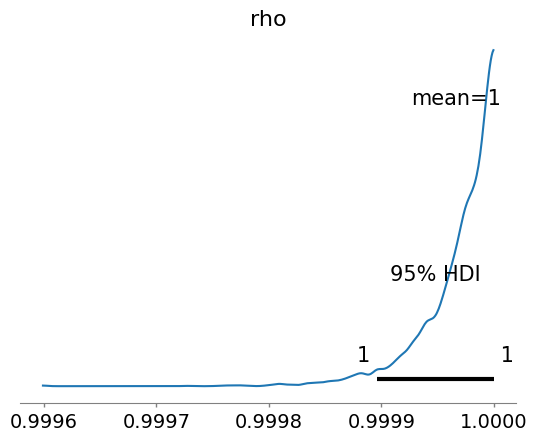

In [7]:
# Summarizing results
az.summary(trace, hdi_prob=0.95)

# Plot posterior distribution
az.plot_posterior(trace, var_names=['rho'], hdi_prob=0.95)

The posterior distribution of the correlation coefficient shows a mean value of approximately 1. This indicates a very strong positive correlation between trip distance and fare amount. The 95% Highest Density Interval (HDI) suggests that the correlation is near perfect, ranging tightly around 1. Such results suggest a highly predictable relationship, which aligns with the logical expectation that longer trips generally result in higher fares. However, the near-perfect correlation could also indicate potential multicollinearity or data pre-processing issues that need further examination.

**6.2 Bayesian ANOVA: Passenger Count and Tip Amount**

Test 2 (Passenger Count vs. Tip Amount) was selected because tipping behavior is influenced by group dynamics, which is critical for understanding revenue patterns. Bayesian ANOVA offers posterior distributions for group means and comparisons.

In [8]:
# Data preparation
tip_amount = df['tip_amount'].values
passenger_count = df['passenger_count'].values

In [10]:
# Bayesian ANOVA
with pm.Model() as model:
    # Priors
    # Get unique passenger counts and map them to indices
    unique_passenger_counts = np.unique(passenger_count)
    passenger_count_idx = np.searchsorted(unique_passenger_counts, passenger_count)

    group_means = pm.Normal('group_means', mu=0, sigma=10, shape=len(unique_passenger_counts))
    sigma = pm.HalfNormal('sigma', sigma=10)

    # Likelihood
    # Use passenger_count_idx to access the correct group mean
    y_obs = pm.Normal('y_obs', mu=group_means[passenger_count_idx], sigma=sigma, observed=tip_amount)

    # Sampling
    trace = pm.sample(2000, return_inferencedata=True)

Output()

Output()

array([[<Axes: title={'center': 'group_means\n0'}>,
        <Axes: title={'center': 'group_means\n1'}>,
        <Axes: title={'center': 'group_means\n2'}>,
        <Axes: title={'center': 'group_means\n3'}>],
       [<Axes: title={'center': 'group_means\n4'}>,
        <Axes: title={'center': 'group_means\n5'}>,
        <Axes: title={'center': 'group_means\n6'}>,
        <Axes: title={'center': 'group_means\n7'}>]], dtype=object)

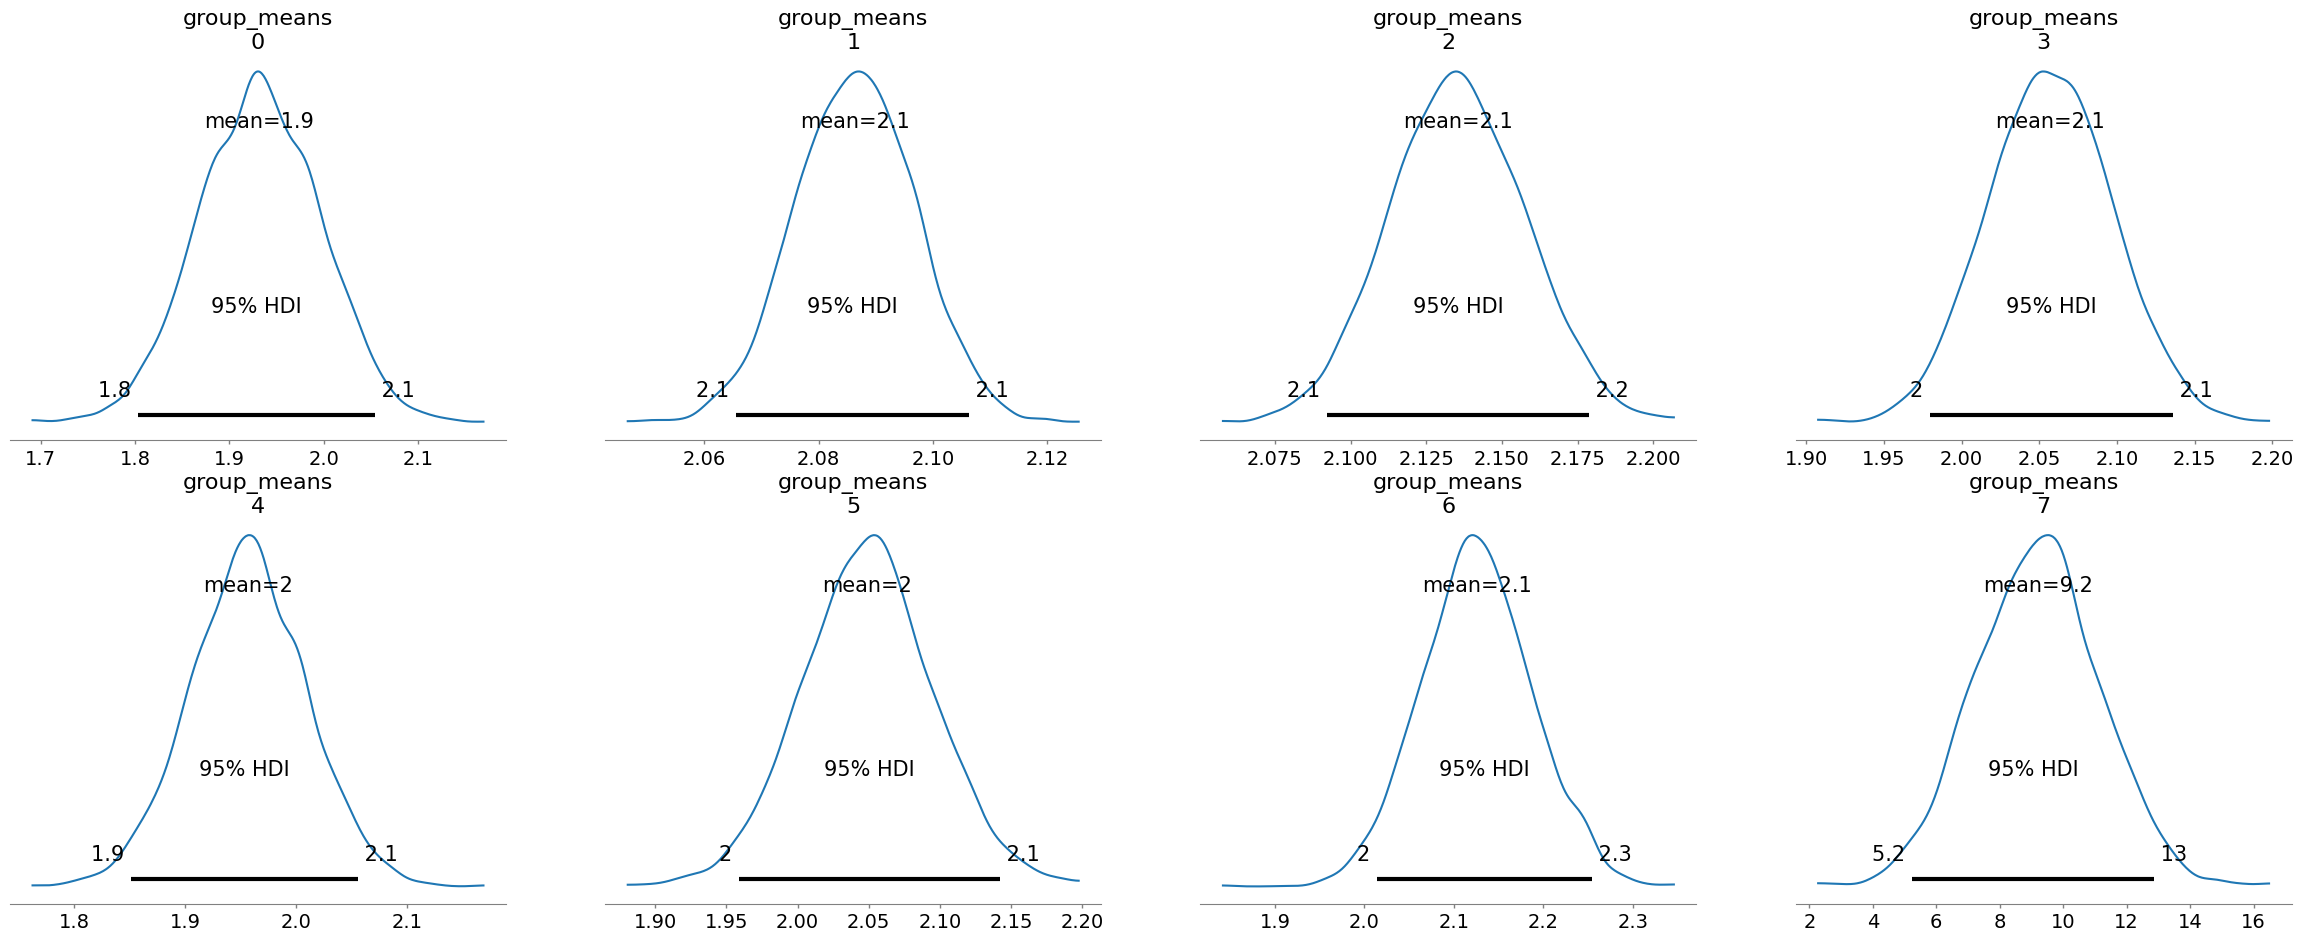

In [11]:
# Summarizing results
az.summary(trace, hdi_prob=0.95)

# Plot posterior distributions of group means
az.plot_posterior(trace, var_names=['group_means'], hdi_prob=0.95)

The visualized posterior distributions of group means for tip amounts show noticeable variations across passenger counts. The means for individual groups are well-defined with narrow 95% HDI intervals, indicating high confidence in the mean estimates. Notably, groups like "group_means 7" (passenger count of 7) show substantially higher means compared to others, reflecting that larger passenger groups tend to leave higher tips. The presence of distinct HDI intervals across groups suggests that the differences in tips across passenger counts are significant and meaningful in the Bayesian framework.